# Experiment 2

Idea: Incorporate fairness into the reward

In [2]:
import copy

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from stable_baselines3.ppo import PPO

from config import (
    CALENDAR_SEED,
    DEMAND_MODEL_PRICE_GRANULARITY,
    FAIRNESS_WEIGHTS_LIST,
    FIGURES_PATH,
    N_SNAP_DAYS,
    NOISE_RANGE,
    NUM_INITIAL_RUNS,
    NUM_PRODUCTS,
    NUM_TIMESTEPS,
    P_DIFF,
    P_MAX,
    P_MIN,
    PPO_HYPERPARAMS,
    PPO_WARMUP_NR_EPISODES,
    SEED_LIST,
    K,
)
from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator
from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.experiment_utils import argmedian
from fair_dynamic_pricing_with_rl.utils.fairness_utils import compute_jains_index


In [3]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [5]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = DEMAND_MODEL_PRICE_GRANULARITY,
    verbose = False # demand parameters were shown in experiment 1
)

demand_model_parameters = demand_model_estimator.run_pipeline()

## New environment with modified objective, including Jain's index.

In [15]:
class FMCGEnv2(FMCGEnv):
    def __init__(
        self,
        p_min: np.ndarray,
        p_max: np.ndarray,
        p_diff: np.ndarray,
        betas: list,
        noise_range: int,
        max_demand: int,
        n_snap_days: int,
        max_revenue: float,
        stand_params: np.ndarray=None,
        calendar_seed=None,
        T: int = 365,
        rew_weights=None,
    ):
        """Initialize FMCG Gymnasium environment.

        Args:
            p_min (np.array): minimum price vector of products (L)
            p_max (np.array): maximum price vector of products (L)
            p_diff (np.array): price step vector of products (L)
            betas (List[np.ndarray]): demand core state param. for non-SNAP and SNAP households
            noise_range (int): maximum value of noise (symmetric)
            max_demand (int): the maximum daily demand considering all L products
            n_snap_days (int): number of SNAP days in a 30-day month.
            max_revenue (float): max historical daily revenue
            stand_params (np.ndarray): mean and standard deviation of revenue and Jain's index (defaults to None)
            calendar_seed (int, optional): seed used for constructing SNAP calendar
            T (int, optional): length of episode (defaults to 365),
            rew_weights (np.ndarray): reward weights for profits vs. fairness tradeoff (default: 50-50%)
        """
        super().__init__(p_min, p_max,p_diff,
                         betas, noise_range, max_demand, n_snap_days, calendar_seed,
                         T)
        # reward weights default to equal weighting
        if rew_weights is None:
            self.rew_weights = np.array([0.5,0.5])
        else:
            self.rew_weights = rew_weights

        # defining new attributes
        self._max_revenue = max_revenue
        self._stand_params = stand_params

    def _get_reward(self,
                    p: np.ndarray,
                    d: np.ndarray,
                    ):
        """ Returns reward, weighted avg. of standardized revenue and Jain's index
        Args:
            p (np.ndarray): price vector (L)
            d (np.ndarray): demand vector (L)

        Returns:
            reward (float): reward from taking action p at the given state
        """
        # the revenue is divided by the historical daily maximum to 
        # make the two components similar in magnitude
        revenue = (p @ d) / self._max_revenue

        # groups are esentially the sensitive attribute mask with length t
        mask_t = np.resize(self.mask, self._t)

        jains_index, _ = compute_jains_index(action_hist=self.action_history,
                                          groups=mask_t,
                                          p_min=self.p_min,
                                          p_diff=self.p_diff)

        # standardizing reward components if not initial run
        if self._stand_params is not None:
            revenue = (revenue - self._stand_params[0,0]) / self._stand_params[0,1]
            jains_index = (jains_index - self._stand_params[1,0]) / self._stand_params[1,1]

        # weight the components of the reward
        reward = np.dot(np.array([revenue,jains_index]), self.rew_weights)
        return reward

    def _get_info(self):
        """Returns revenue"""
        # note: info returned during reset() will be 0
        if self._t > 0:
            # when _get_info() is called, t was already increased
            action = self.action_history[self._t-1, :]
            p = self._action_to_price(action)

            revenue = p @ self._demand

            # return Jain's index for standardization
            # groups are esentially the sensitive attribute mask with length t
            mask_t = np.resize(self.mask, self._t-1)

            jains_index, _ = compute_jains_index(action_hist=self.action_history,
                                                groups=mask_t,
                                                p_min=self.p_min,
                                                p_diff=self.p_diff)
        else:
            revenue, jains_index = 0, 0

        return {"revenue": revenue, "jains_index": jains_index}

In [16]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv2",
    entry_point=FMCGEnv2,
    max_episode_steps=500,  # Prevent infinite episodes
)

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\envs\registration.py:637: UserWarning: WARN: Overriding environment gymnasium_env/FMCGEnv2 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [17]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  seed=None,
                  initial:bool = False):
    """ Running PPO algorithm

    Args:
        env1 (FMCGEnv2): the defined gym environment
        alg (stable_baselines3.PPO): PPO policy
        T (int): number of timesteps per episode
        K (int): number of episodes
        num_products (int): number of products
        seed (int): seed for reproducibility
        initial (bool): whether it is the initial run for standardization (defaults to False)

    Returns:
        rew (np.ndarray): rewards (T,K)
        action_hist (np.ndarray): action history (T,K,L)
        groups (np.ndarray): groups according to binary sensitive attribute (T,K)
    """

    env = copy.deepcopy(env1)

    if initial:
        rew = np.zeros((T,K,2))
    else:
        rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        for t in range(T):
            # save the group wrt. sensitive attribute
            groups[t,k] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=True)
            a = np.asarray(action)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)

            # revenue is taken to keep analysis consistent between experiments
            if not initial:
                rew[t,k] = info["revenue"]
            else:
                rew[t,k,0] = info["revenue"]
                rew[t,k,1] = info["jains_index"]
        
    return rew, action_hist, groups

## For standardization of reward components their mean and standard deviation is estimated using initial runs

In [ ]:
fair_w = 0.5
env = gym.make("gymnasium_env/FMCGEnv2",
        p_min=P_MIN,
        p_max=P_MAX,
        p_diff=P_DIFF,
        betas=[params.to_numpy() for params in demand_model_parameters[3]],
        max_demand=demand_model_parameters[4],
        n_snap_days=N_SNAP_DAYS,
        max_revenue=demand_model_parameters[5],
        calendar_seed=CALENDAR_SEED,
        noise_range=NOISE_RANGE,
        rew_weights=np.array([1-fair_w, fair_w])
        )

# define and warm-up algorithm
# PPO hyperparameters from Liu et al. (2024)
model = PPO(policy="MultiInputPolicy",
            env=env,
            learning_rate=PPO_HYPERPARAMS["learning_rate"],
            batch_size=PPO_HYPERPARAMS["batch_size"], # default
            clip_range=PPO_HYPERPARAMS["clip_range"], # default
            seed=PPO_HYPERPARAMS["seed"])

model.learn(total_timesteps=PPO_WARMUP_NR_EPISODES,
            progress_bar=False)

reward_components, _, _ = running_model(env1=env,
                                        alg=model,
                                        T=NUM_TIMESTEPS,
                                        K=NUM_INITIAL_RUNS,
                                        num_products=NUM_PRODUCTS,
                                        seed=SEED_LIST[0],
                                        initial=True)

# note for the Jain's index history NA values are expected up to the time step where both groups have
# price history
standardization_params = np.array([np.mean(reward_components[:,:,0]),np.std(reward_components[:,:,0])],
                                  [np.nanmean(reward_components[:,:,1]),np.nanstd(reward_components[:,:,1])])

c:\Users\Kim Levente\Documents\01-projects\research-project\03_poc\codes\fair-dynamic-pricing-with-rl\src\fair_dynamic_pricing_with_rl\utils\fairness_utils.py:39: RuntimeWarning: invalid value encountered in scalar divide
  jains_index = (x.sum() ** 2) / (n * np.sum(x**2))


In [39]:
K=100

In [40]:
# storing expected mean episode rewards
episode_rewards_comparison = np.zeros((K*len(FAIRNESS_WEIGHTS_LIST),3))
# storing Jain's indexes and mean episode revenues
results = pd.DataFrame(np.zeros((len(FAIRNESS_WEIGHTS_LIST),5)),
                       columns=["mean_episode_revenue","jains_index","fairness_weight", "nonsnap_price", "snap_price"])

rewards_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))
action_hist_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K,NUM_PRODUCTS))
groups_over_seeds = np.zeros((len(SEED_LIST),NUM_TIMESTEPS,K))

for idx in range(len(FAIRNESS_WEIGHTS_LIST)):
    for seed_idx in range(len(SEED_LIST)):
        # make environment with chosen revenue - fairness weights
        fair_w = FAIRNESS_WEIGHTS_LIST[idx]
        env = gym.make("gymnasium_env/FMCGEnv2",
                p_min=P_MIN,
                p_max=P_MAX,
                p_diff=P_DIFF,
                betas=[params.to_numpy() for params in demand_model_parameters[3]],
                max_demand=demand_model_parameters[4],
                n_snap_days=N_SNAP_DAYS,
                max_revenue=demand_model_parameters[5],
                stand_params=standardization_params,
                calendar_seed=CALENDAR_SEED,
                noise_range=NOISE_RANGE,
                rew_weights=np.array([1-fair_w, fair_w])
                )

        # define and warm-up algorithm
        # PPO hyperparameters from Liu et al. (2024)
        model = PPO(policy="MultiInputPolicy",
                    env=env,
                    learning_rate=PPO_HYPERPARAMS["learning_rate"],
                    batch_size=PPO_HYPERPARAMS["batch_size"], # default
                    clip_range=PPO_HYPERPARAMS["clip_range"], # default
                    seed=PPO_HYPERPARAMS["seed"])

        model.learn(total_timesteps=PPO_WARMUP_NR_EPISODES,
                    progress_bar=False)

        rewards, action_hist, groups = running_model(env1=env,
                                                alg=model,
                                                T=NUM_TIMESTEPS,
                                                K=K,
                                                num_products=NUM_PRODUCTS,
                                                seed=SEED_LIST[seed_idx])

        rewards_over_seeds[seed_idx, ...] = rewards
        action_hist_over_seeds[seed_idx, ...] = action_hist
        groups_over_seeds[seed_idx, ...] = groups

    # choose based on median of last episode reward
    last_episode_rewards_over_seeds = rewards_over_seeds.sum(axis=1)[:,-1]
    median_seed_idx = argmedian(last_episode_rewards_over_seeds)

    rewards_chosen = rewards_over_seeds[median_seed_idx,...]
    action_hist_chosen = action_hist_over_seeds[median_seed_idx,...]
    groups_chosen = groups_over_seeds[median_seed_idx,...]
    
    episode_rewards = rewards_chosen.sum(axis=0)
    e_mean_episode_reward = episode_rewards.cumsum() / (np.arange(K) + 1)

    # expected mean episode rewards
    episode_rewards_comparison[(idx*K):((idx+1)*K),0] = np.arange(K)
    episode_rewards_comparison[(idx*K):((idx+1)*K),1] = e_mean_episode_reward

    # random action probability
    episode_rewards_comparison[(idx*K):((idx+1)*K),2] = FAIRNESS_WEIGHTS_LIST[idx]

    # save main performance metrics
    results.loc[idx,"fairness_weight"] = FAIRNESS_WEIGHTS_LIST[idx]
    results.loc[idx,"mean_episode_revenue"] = episode_rewards.mean()
    results.loc[idx, "jains_index"], group_values = compute_jains_index(action_hist_chosen,
                                                                        groups_chosen,
                                                                        p_min=P_MIN,
                                                                        p_diff=P_DIFF)
    results.loc[idx, "nonsnap_price"] = group_values[False]
    results.loc[idx, "snap_price"] = group_values[True]

c:\Users\Kim Levente\Documents\01-projects\research-project\03_poc\codes\fair-dynamic-pricing-with-rl\src\fair_dynamic_pricing_with_rl\utils\fairness_utils.py:39: RuntimeWarning: invalid value encountered in scalar divide
  jains_index = (x.sum() ** 2) / (n * np.sum(x**2))


In [41]:
# save & print results, note the Windows-specific path(!)
results.to_csv("..\\output\\experiment_2\\results.csv",
               index=False)
results

,mean_episode_revenue,jains_index,fairness_weight,nonsnap_price,snap_price
0,702.897965,0.979423,0.000000,15.830000,11.822000
1,518.675009,0.977924,0.111111,15.830000,11.694500
2,1061.144105,0.979880,0.222222,15.720000,11.779500
3,2177.896554,0.985091,0.333333,15.610000,12.190000
4,5001.846890,0.994821,0.444444,15.499780,13.413690
5,8939.611052,0.998701,0.555556,15.421340,14.347780
6,12344.404572,0.999922,0.666667,14.339085,14.088000
7,11094.422996,0.998452,0.777778,13.906557,12.852780
8,298.986037,0.999983,0.888889,14.469000,14.350000
9,5074.315445,0.999761,1.000000,14.078780,13.650335


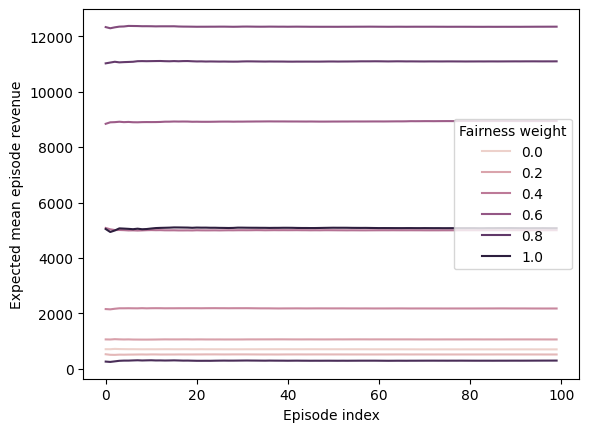

In [43]:
episode_rewards_comparison_df = pd.DataFrame(episode_rewards_comparison,
                                             columns=["episode_idx", "mean_episode_revenue", "fairness_weight"])

# for plotting every episode ex. first x: data = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx > 50.0],
sns.lineplot(data = episode_rewards_comparison_df,
             x="episode_idx",
             y="mean_episode_revenue",
             hue="fairness_weight")
plt.xlabel("Episode index")
plt.ylabel("Expected mean episode revenue")
plt.legend(title="Fairness weight", loc="center right")
plt.savefig(FIGURES_PATH + "experiment_2_revenue_over_time.pdf", format="pdf", bbox_inches="tight")

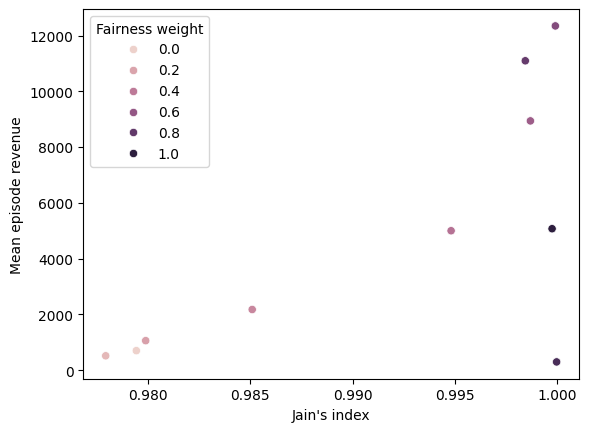

In [45]:
sns.scatterplot(data=results, x="jains_index", y="mean_episode_revenue",
                hue="fairness_weight")
plt.xlabel("Jain's index")
plt.ylabel("Mean episode revenue")
plt.legend(title="Fairness weight", loc="upper left")
plt.savefig(FIGURES_PATH + "experiment_2_revenue_vs_jains.pdf", format="pdf", bbox_inches="tight")